In [21]:
import os
import sys

import numpy as np

current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)


In [22]:
from src.models.train_model.train_model import *

In [23]:
goodness_to_select = 5

In [24]:
save_model_folder = os.path.join(project_root, "src", "models", "fitted_models")

df_r_selected = select_data(goodness_to_select)

features = ["name", "code", "temp_sens"]
df_f_selected = select_features(df_r_selected, features)

ds_n_c = Data_selector(df_f_selected)
ds_n_c.df = ds_n_c.df.dropna()
power_plants = ds_n_c.df[['name', 'code']].drop_duplicates()
train_errors, test_errors, data_sizes = [], [], []
for row in power_plants.itertuples():
    name, code = row.name, row.code
    logger.info(f"Train and test data related to {name}_{code}:")

    df_n_c = ds_n_c.filter_name_code(name, code)

    fs_n_c = Feature_selector(df_n_c, "generation")
    fs_n_c.filter_features(features_to_drop=["name", "code"])
    X, y = fs_n_c.get_X_and_y()

    train_error, test_error = train_and_test_model(X, y, save_model_folder, name, code)
    logger.info(
        f"Train rmse error: {train_error:.3f}%, Test rmse error: {test_error:.3f}% , Size of data: {len(y)}")

    train_errors.append(train_error)
    test_errors.append(test_error)
    data_sizes.append(len(y))

print_report(data_sizes, train_errors, test_errors)

2025-10-25 11:32:59 - src.models.train_model.train_model - INFO - Rows with goodness=5 have been selected
2025-10-25 11:32:59 - src.models.train_model.train_model - INFO - Features have been selected successfully
2025-10-25 11:32:59 - src.models.train_model.train_model - INFO - Train and test data related to جنوب اصفهان - چهلستون_G11:
2025-10-25 11:32:59 - src.models.train_model.train_model - INFO - Train rmse error: 1.602%, Test rmse error: 2.656% , Size of data: 756
2025-10-25 11:32:59 - src.models.train_model.train_model - INFO - Train and test data related to جنوب اصفهان - چهلستون_G12:
2025-10-25 11:32:59 - src.models.train_model.train_model - INFO - Train rmse error: 0.218%, Test rmse error: 0.736% , Size of data: 5
2025-10-25 11:32:59 - src.models.train_model.train_model - INFO - Train and test data related to جنوب اصفهان - چهلستون_G13:
2025-10-25 11:32:59 - src.models.train_model.train_model - INFO - Train rmse error: 0.160%, Test rmse error: 0.447% , Size of data: 5
2025-10-25 

In [25]:
all_name_codes = np.array([(row.name,row.code) for row in power_plants.itertuples()])

In [26]:
all_name_codes

array([['جنوب اصفهان - چهلستون', 'G11'],
       ['جنوب اصفهان - چهلستون', 'G12'],
       ['جنوب اصفهان - چهلستون', 'G13'],
       ['جنوب اصفهان - چهلستون', 'G14'],
       ['جنوب اصفهان - چهلستون', 'G15'],
       ['جنوب اصفهان - چهلستون', 'G16'],
       ['حافظ', 'G11'],
       ['حافظ', 'G12'],
       ['حافظ', 'G13'],
       ['حافظ', 'G14'],
       ['حافظ', 'G15'],
       ['حافظ', 'G16'],
       ['سبلان', 'G11'],
       ['سبلان', 'G12'],
       ['سبلان', 'G13'],
       ['سبلان', 'G14'],
       ['سبلان', 'G15'],
       ['سبلان', 'G16'],
       ['سیکل ترکیبی ارومیه', 'G11'],
       ['سیکل ترکیبی ارومیه', 'G12'],
       ['سیکل ترکیبی ارومیه', 'G13'],
       ['سیکل ترکیبی ارومیه', 'G14'],
       ['سیکل ترکیبی ارومیه', 'G15'],
       ['سیکل ترکیبی ارومیه', 'G16'],
       ['سیکل ترکیبی شیروان', 'G11'],
       ['سیکل ترکیبی شیروان', 'G12'],
       ['سیکل ترکیبی شیروان', 'G13'],
       ['سیکل ترکیبی شیروان', 'G14'],
       ['سیکل ترکیبی شیروان', 'G15'],
       ['سیکل ترکیبی شیروان', 'G16'],
    

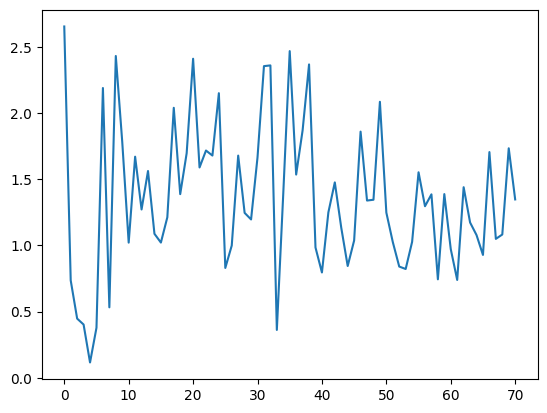

In [27]:
import matplotlib.pyplot as plt
plt.plot(test_errors)

In [30]:
test_errors = np.array(test_errors)
all_name_codes[test_errors>=2.6]

array([['جنوب اصفهان - چهلستون', 'G11']], dtype='<U21')

(array([34.,  3.,  9.,  8.,  7.,  7.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  1.,  0.,  1.]),
 array([   5. ,  251.8,  498.6,  745.4,  992.2, 1239. , 1485.8, 1732.6,
        1979.4, 2226.2, 2473. , 2719.8, 2966.6, 3213.4, 3460.2, 3707. ,
        3953.8, 4200.6, 4447.4, 4694.2, 4941. ]),
 <BarContainer object of 20 artists>)

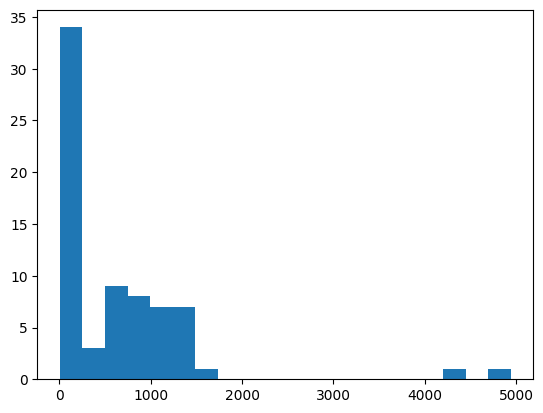

In [34]:
plt.hist(data_sizes,bins=20)

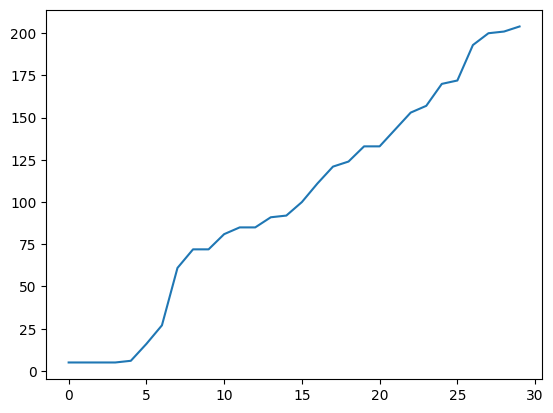

In [41]:
plt.plot(np.sort(data_sizes)[:30])

In [36]:
len(data_sizes)

71

In [37]:
len(power_plants)

71

In [38]:
df_r_selected[["name","code"]].drop_duplicates()

,name,code
73,جنوب اصفهان - چهلستون,G11
13072,جنوب اصفهان - چهلستون,G12
13548,جنوب اصفهان - چهلستون,G13
14024,جنوب اصفهان - چهلستون,G14
14500,جنوب اصفهان - چهلستون,G15
...,...,...
711274,گیلان,G12
723344,گیلان,G13
735394,گیلان,G14
755971,گیلان,G15
